<a href="https://colab.research.google.com/github/BasithMrasak/audio-event-detection/blob/main/audio_event_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Audio Event Detection on ESC-50

This notebook implements an end-to-end audio event detection pipeline
including dataset loading, data augmentation, log-mel feature extraction,
CNN training and evaluation using accuracy, F1-score, confusion matrix and
macro-averaged ROC-AUC.

In [1]:
import os
import pandas as pd

class ESC50DatasetIndex:
    def __init__(self, esc50_root):
        self.esc50_root = esc50_root
        self.meta = pd.read_csv(
            os.path.join(esc50_root, "meta", "esc50.csv")
        )

    def get_split(self, train=True):
        if train:
            return self.meta[self.meta["fold"] != 5].reset_index(drop=True)
        else:
            return self.meta[self.meta["fold"] == 5].reset_index(drop=True)

    def audio_path(self, filename):
        return os.path.join(self.esc50_root, "audio", filename)

**Feature Exractor**

In [13]:
import librosa
import numpy as np

def extract_logmel_from_wave(y, sr=22050, n_mels=128):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=n_mels
    )
    logmel = librosa.power_to_db(mel, ref=np.max)
    return logmel

In [19]:
import librosa

root = "/content/drive/MyDrive/ESC-50-master"

ds = ESC50DatasetIndex(root)

train_df = ds.get_split(train=True)
row = train_df.iloc[0]

wav_path = ds.audio_path(row["filename"])
y, sr = librosa.load(wav_path, sr=22050) # Load the audio file
spec = extract_logmel_from_wave(y, sr=sr)

print(spec.shape)
print(row["category"])

print(spec.min(), spec.max())

(128, 216)
dog
-80.0 0.0


**Augmentation**

In [20]:
import random
import torch

# ---------- waveform level ----------
def random_time_shift(wave, max_shift=0.1):
    shift = int(random.uniform(-max_shift, max_shift) * wave.shape[-1])
    return torch.roll(wave, shifts=shift, dims=-1)

def add_noise(wave, noise_level=0.005):
    noise = torch.randn_like(wave) * noise_level
    return wave + noise


# ---------- spectrogram level (SpecAugment) ----------
def spec_augment(spec, time_mask=20, freq_mask=15):
    # spec: [1, F, T]
    _, F, T = spec.shape

    # time mask
    t = random.randint(0, time_mask)
    t0 = random.randint(0, max(1, T - t))
    spec[:, :, t0:t0+t] = 0

    # freq mask
    f = random.randint(0, freq_mask)
    f0 = random.randint(0, max(1, F - f))
    spec[:, f0:f0+f, :] = 0

    return spec

**Dataset**

In [21]:
import torch
from torch.utils.data import Dataset
import librosa

from __main__ import ESC50DatasetIndex, random_time_shift, add_noise, spec_augment
from __main__ import extract_logmel_from_wave

class ESC50TorchDataset(Dataset):

    def __init__(self, esc50_root, train=True, augment=False):
        self.index = ESC50DatasetIndex(esc50_root)
        self.df = self.index.get_split(train=train)

        self.train = train
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]
        wav_path = self.index.audio_path(row["filename"])
        label = int(row["target"])

        # -------- load waveform --------
        y, sr = librosa.load(wav_path, sr=22050)
        y = torch.tensor(y, dtype=torch.float32)

        # -------- waveform augmentation --------
        if self.train and self.augment:
            y = random_time_shift(y)
            y = add_noise(y)

        # -------- log-mel extraction --------
        y_np = y.numpy()
        logmel = extract_logmel_from_wave(y_np, sr=22050, n_mels=128)

        spec = torch.tensor(logmel, dtype=torch.float32).unsqueeze(0)

        # -------- spectrogram augmentation --------
        if self.train and self.augment:
            spec = spec_augment(spec)

        return spec, label

In [22]:
ESC50_ROOT = "/content/drive/MyDrive/ESC-50-master"

train_ds = ESC50TorchDataset(
    ESC50_ROOT,
    train=True,
    augment=True      # ✅ augmentation ON
)

val_ds = ESC50TorchDataset(
    ESC50_ROOT,
    train=False,
    augment=False     # ✅ augmentation OFF
)

In [23]:
ds = ESC50TorchDataset(
    "/content/drive/MyDrive/ESC-50-master",
    train=True,
    augment=True
)

x, y = ds[0]
print(x.shape, y)
print(x.min().item(), x.max().item())

torch.Size([1, 128, 216]) 0
-65.74409484863281 0.0


**DataLoader**

In [24]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [8]:
import torch.nn as nn

class AudioCNN(nn.Module):

    def __init__(self, num_classes=50):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [9]:
pip install -q torchinfo

In [10]:
from torchinfo import summary

model = AudioCNN()
summary(
    model,
    input_size=(1, 1, 128, 216),   # (batch, channels, mel, time)
    device=str(next(model.parameters()).device)
)

Layer (type:depth-idx)                   Output Shape              Param #
AudioCNN                                 [1, 50]                   --
├─Sequential: 1-1                        [1, 64, 32, 54]           --
│    └─Conv2d: 2-1                       [1, 16, 128, 216]         160
│    └─BatchNorm2d: 2-2                  [1, 16, 128, 216]         32
│    └─ReLU: 2-3                         [1, 16, 128, 216]         --
│    └─MaxPool2d: 2-4                    [1, 16, 64, 108]          --
│    └─Conv2d: 2-5                       [1, 32, 64, 108]          4,640
│    └─BatchNorm2d: 2-6                  [1, 32, 64, 108]          64
│    └─ReLU: 2-7                         [1, 32, 64, 108]          --
│    └─MaxPool2d: 2-8                    [1, 32, 32, 54]           --
│    └─Conv2d: 2-9                       [1, 64, 32, 54]           18,496
│    └─ReLU: 2-10                        [1, 64, 32, 54]           --
├─AdaptiveAvgPool2d: 1-2                 [1, 64, 1, 1]             --
├─Seque

**Training**

In [11]:
import torch
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AudioCNN(num_classes=50).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()


def run_epoch(loader, train=True):

    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0
    correct = 0
    total = 0

    for x, y in tqdm(loader):

        x = x.to(device)
        y = y.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            out = model(x)
            loss = criterion(out, y)

            if train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

In [12]:
for epoch in range(10):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc     = run_epoch(val_loader, train=False)

    print(f"Epoch {epoch+1}")
    print(f"  Train loss: {train_loss:.4f}, acc: {train_acc:.4f}")
    print(f"  Val   loss: {val_loss:.4f}, acc: {val_acc:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 13/13 [01:12<00:00,  5.54s/it]


Epoch 1
  Train loss: 3.8622, acc: 0.0306
  Val   loss: 3.7500, acc: 0.0375


100%|██████████| 13/13 [00:19<00:00,  1.50s/it]


Epoch 2
  Train loss: 3.6879, acc: 0.0362
  Val   loss: 3.9271, acc: 0.0375


100%|██████████| 13/13 [00:21<00:00,  1.65s/it]


...

Epoch 8
  Train loss: 3.2592, acc: 0.0938
  Val   loss: 3.9247, acc: 0.0625


100%|██████████| 13/13 [00:21<00:00,  1.63s/it]


Epoch 9
  Train loss: 3.1892, acc: 0.1263
  Val   loss: 3.3720, acc: 0.1300


100%|██████████| 13/13 [00:21<00:00,  1.62s/it]

Epoch 10
  Train loss: 3.1171, acc: 0.1281
  Val   loss: 3.4904, acc: 0.0825


**Evaluation**

In [25]:
!pip install -q scikit-learn

In [26]:
import torch
import numpy as np

model.eval()

all_probs = []
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in val_loader:

        x = x.to(device)

        out = model(x)
        probs = torch.softmax(out, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(out.argmax(1).cpu().numpy())
        all_targets.append(y.numpy())

all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

print(all_probs.shape, all_preds.shape, all_targets.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


(400, 50) (400,) (400,)


In [27]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_targets,
        all_preds,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         8
           1     0.0000    0.0000    0.0000         8
           2     0.0000    0.0000    0.0000         8
           3     0.8000    0.5000    0.6154         8
           4     0.0000    0.0000    0.0000         8
           5     0.0000    0.0000    0.0000         8
           6     0.0000    0.0000    0.0000         8
           7     0.0000    0.0000    0.0000         8
           8     0.0000    0.0000    0.0000         8
           9     0.0000    0.0000    0.0000         8
          10     0.1429    0.2500    0.1818         8
          11     0.0556    0.1250    0.0769         8
          12     0.0000    0.0000    0.0000         8
          13     0.0000    0.0000    0.0000         8
          14     0.0000    0.0000    0.0000         8
          15     0.0000    0.0000    0.0000         8
          16     0.0000    0.0000    0.0000         8
          17     0.0000    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


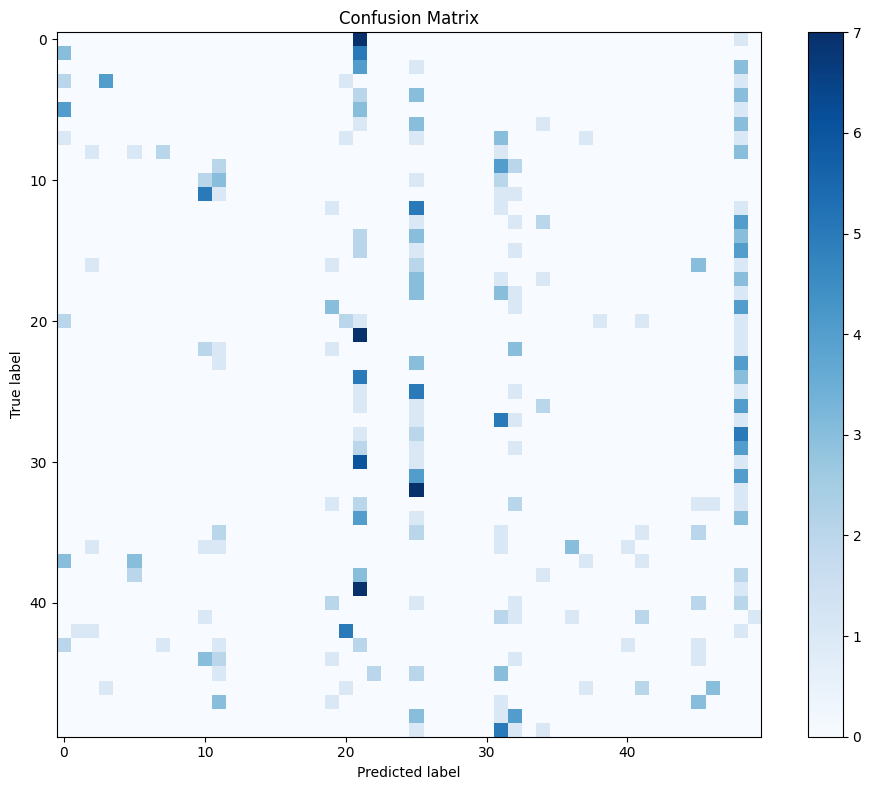

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import roc_auc_score

roc_auc_ovr = roc_auc_score(
    all_targets,
    all_probs,
    multi_class="ovr",
    average="macro"
)

print("ROC-AUC (macro, OvR):", roc_auc_ovr)

ROC-AUC (macro, OvR): 0.7932270408163266


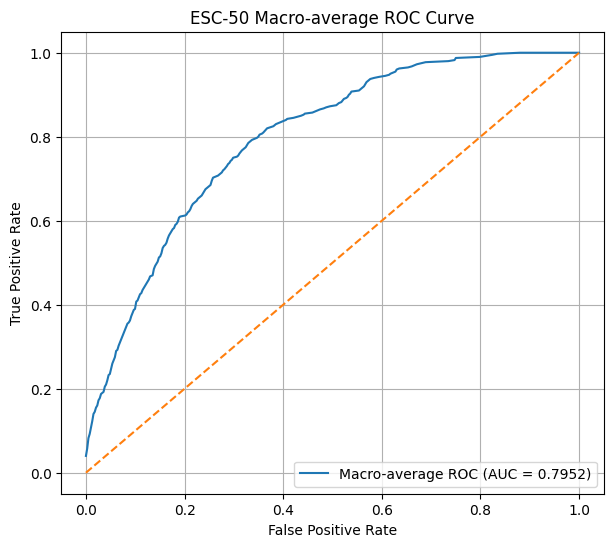

In [30]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = all_probs.shape[1]

y_true_bin = label_binarize(all_targets, classes=np.arange(n_classes))

fpr = dict()
tpr = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])

# macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

macro_auc = auc(all_fpr, mean_tpr)

plt.figure(figsize=(7, 6))
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {macro_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ESC-50 Macro-average ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()